# International Tourism Receipts
## Processing data to find out tourism information
Dataset source: ***https://www.kaggle.com/datasets/abdulhamitcelik/international-tourism-receipts***


### Setup & Imports

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Set visualisation style
sns.set_theme(style='darkgrid')
plt.style.use('seaborn-v0_8-colorblind')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### Load dataset

In [15]:
# Load dataset
print("Loading tourism dataset...")
df = pd.read_csv('tourism-recipts.csv')

print("✅ TOURISM RECEIPTS DATASET")
print("="*60)


# Explore dataset information
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Years covered: {df['year'].min()} - {df['year'].max()}")
print(f"Number of countries: {df['name'].nunique()}")
print(f"Time range: {df['year'].nunique()} years")
print(f"Value range: ${df['value_$'].min():,.0f} - ${df['value_$'].max():,.0f}")


print("\n📊 First 5 rows:")
print(df.head())
print("\n📊 Data types:")
print(df.dtypes)
print("\n📊 Last 5 rows:")
print(df.tail())

Loading tourism dataset...
✅ TOURISM RECEIPTS DATASET
Shape: 4,156 rows, 4 columns
Years covered: 1995 - 2020
Number of countries: 203
Time range: 26 years
Value range: $100,000 - $241,984,000,000

📊 First 5 rows:
          name code  year      value_$
0  Afghanistan  AFG  2008  57000000.00
1  Afghanistan  AFG  2009  89000000.00
2  Afghanistan  AFG  2010 147000000.00
3  Afghanistan  AFG  2011 165000000.00
4  Afghanistan  AFG  2012 167000000.00

📊 Data types:
name           str
code           str
year         int64
value_$    float64
dtype: object

📊 Last 5 rows:
          name code  year      value_$
4151  Zimbabwe  ZWE  2016 194000000.00
4152  Zimbabwe  ZWE  2017 158000000.00
4153  Zimbabwe  ZWE  2018 191000000.00
4154  Zimbabwe  ZWE  2019 285000000.00
4155  Zimbabwe  ZWE  2020  66000000.00


### Initial Data Assessment

In [27]:
# Understanding the dataset
print("🔍 DATA QUALITY CHECK")
print("="*60)

# Check for missing values
print("\n1️⃣ MISSING VALUES:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("    ✅ No missing values found!")
else:
    print(missing[missing > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n2️⃣ DUPLICATES: {duplicates}")

# Check for negative values
negative_values = (df['value_$'] < 0).sum()
print(f"\n3️⃣ NEGATIVE VALUES: {negative_values}")

# Check value distribution
print("\n4️⃣ VALUE STATISTICS:")
print(f"    Mean: ${df['value_$'].mean():,.0f}")
print(f"    Median: ${df['value_$'].median():,.0f}")
print(f"    Std Dev: ${df['value_$'].std():,.0f}")

# Check years per country
years_per_country = df.groupby('name')['year'].count()
print("\n5️⃣ YEARS PER COUNTRY:")
print(f"    Min: {years_per_country.min()}")
print(f"    Max: {years_per_country.max()}")
print(f"    Mean: {years_per_country.mean():.1f}")

# List countries with incomplete data
incomplete = years_per_country[years_per_country < df['year'].nunique()].index.tolist()
if incomplete:
    print(f"\n⚠️ Countries with missing years: {len(incomplete)}")
    print(f"    First 5: {incomplete[:5]}")

🔍 DATA QUALITY CHECK

1️⃣ MISSING VALUES:
    ✅ No missing values found!

2️⃣ DUPLICATES: 0

3️⃣ NEGATIVE VALUES: 0

4️⃣ VALUE STATISTICS:
    Mean: $4,919,326,950
    Median: $749,500,000
    Std Dev: $14,980,536,309

5️⃣ YEARS PER COUNTRY:
    Min: 1
    Max: 26
    Mean: 20.5

⚠️ Countries with missing years: 126
    First 5: ['Afghanistan', 'Algeria', 'American Samoa', 'Andorra', 'Antigua and Barbuda']


### Create Additional Features

In [45]:
# Feature engineering
print("🔧 FEATURE ENGINEERNG")
print("="*60)

# Create a copy for analysis
df_clean = df.copy()

# Convert values to millions for easier reading
df_clean['value_millions'] = df_clean['value_$'] / 1_000_000

# Calculate year-over-year growth
df_clean = df_clean.sort_values(['name', 'year'])
df_clean['prev_year_value'] = df_clean.groupby('name')['value_$'].shift(1)
df_clean['growth_rate'] = ((df_clean['value_$'] - df_clean['prev_year_value']) / df_clean['prev_year_value'] * 100)
df_clean['growth_rate'] = df_clean['growth_rate'].fillna(0)   # First year has no growth

# Add a decade column
df_clean['decade'] = (df_clean['year'] // 10) * 10

# Flag for growth (positive/negative)
df_clean['is_growing'] = df_clean['growth_rate'] > 0

# Categorise growth
def categorise_growth(rate):
    if rate > 20:
        return 'High Growth (>20%)'
    elif rate > 0:
        return 'Positive Growth (0 - 20%)'
    elif rate > -20:
        return 'Mild Decline (-20% to 0)'
    else:
        return 'Sharp Decline (< -20%)'

df_clean['growth_category'] = df_clean['growth_rate'].apply(categorise_growth)

print("✅ Added columns:")
print("    - value_millions (values in millions)")
print("    - prev_year_value (previous year's receipts)")
print("    - growth_rate (year-over-year % change)")
print("    - decade (grouped by decade)")
print("    - is_growing (boolean flag)")
print("    - growth_category (categorized growth)")  

print(f"\n📊 New shape: {df_clean.shape}")
df_clean.head()

🔧 FEATURE ENGINEERNG
✅ Added columns:
    - value_millions (values in millions)
    - prev_year_value (previous year's receipts)
    - growth_rate (year-over-year % change)
    - decade (grouped by decade)
    - is_growing (boolean flag)
    - growth_category (categorized growth)

📊 New shape: (4156, 10)


,name,code,year,value_$,value_millions,prev_year_value,growth_rate,decade,is_growing,growth_category
0,Afghanistan,AFG,2008,57000000.00,57.00,NaN,0.00,2000,False,Mild Decline (-20% to 0)
1,Afghanistan,AFG,2009,89000000.00,89.00,57000000.00,56.14,2000,True,High Growth (>20%)
2,Afghanistan,AFG,2010,147000000.00,147.00,89000000.00,65.17,2010,True,High Growth (>20%)
3,Afghanistan,AFG,2011,165000000.00,165.00,147000000.00,12.24,2010,True,Positive Growth (0 - 20%)
4,Afghanistan,AFG,2012,167000000.00,167.00,165000000.00,1.21,2010,True,Positive Growth (0 - 20%)


### Analysing Global Trends

In [35]:
# Global trends
print("🌍 GLOBAL TOURISM RECEIPTS ANALYSIS")
print("="*60)

# Gloabl totals by year
global_totals = df_clean.groupby('year')['value_millions'].sum().reset_index()

print("\n1️⃣ GLOBAL TOURISM RECEIPTS OVER TIME:")
for _, row in global_totals.iterrows():
    year = int(row['year'])
    value = row['value_millions']
    # Creating a simple bar chart in text
    bar = '█' * int(value / 20000)  # Scale for display
    print(f"   {year}: {bar} ${value:,.0f}M")

# Growth years
print("\n2️⃣ BEST YEARS FOR GLOBAL TOURISM:")
top_years = global_totals.nlargest(5, 'value_millions')
for _, row in top_years.iterrows():
    print(f"    {int(row['year'])}: ${row['value_millions']:,.0f}M")

print("\n3️⃣ COVID-19 IMPACT (2019 vs 2020:")
if 2019 in df_clean['year'].values and 2020 in df_clean['year'].values:
    receipt_2019 = global_totals[global_totals['year'] == 2019]['value_millions'].values[0]
    receipt_2020 = global_totals[global_totals['year'] == 2020]['value_millions'].values[0]
    decline = ((receipt_2020 - receipt_2019) / receipt_2019) * 100
    print(f"    2019: ${receipt_2019:,.0f}M")
    print(f"    2020: ${receipt_2020:,.0f}M")
    print(f"    Change: {decline:.1f}%")

🌍 GLOBAL TOURISM RECEIPTS ANALYSIS

1️⃣ GLOBAL TOURISM RECEIPTS OVER TIME:
   1995: █████████████████████ $423,343M
   1996: ██████████████████████ $450,460M
   1997: █████████████████████ $435,308M
   1998: █████████████████████ $439,252M
   1999: ██████████████████████ $447,574M
   2000: ███████████████████████ $461,370M
   2001: ███████████████████████ $460,506M
   2002: ████████████████████████ $485,579M
   2003: ███████████████████████████ $540,778M
   2004: ███████████████████████████████ $637,947M
   2005: █████████████████████████████████ $661,027M
   2006: ██████████████████████████████████ $694,518M
   2007: ████████████████████████████████████████ $814,430M
   2008: █████████████████████████████████████████ $836,716M
   2009: ██████████████████████████████████████ $761,184M
   2010: ██████████████████████████████████████████ $842,844M
   2011: ██████████████████████████████████████████████ $938,397M
   2012: █████████████████████████████████████████████████ $997,591M
   2013

### Analyse Country Earnings

In [39]:
# Which countries earn the most from tourism
print("🏆 TOP TOURISM EARNERS")
print("="*50)

# Calculate recepts by country
country_totals = df_clean.groupby('name')['value_millions'].sum().sort_values(ascending=False)

print("\n1️⃣ ALL-TIME TOP 10 TOURISM EARNERS:")
for i, (country, value) in enumerate(country_totals.head(10).items(), 1):
    print(f"    {i:2d}. {country:<30} ${value:,.0f}M")

# Last year (2020) performance
latest_year = df_clean['year'].max()
latest_receipts = df_clean[df_clean['year'] == latest_year].set_index('name')['value_millions'].sort_values(ascending=False)

print("\n2️⃣ TOP 10 IN {latest_year} (COVID year):")
for i, (country, value) in enumerate(latest_receipts.head(10).items(), 1):
    print(f"    {i:2d}. {country:<30} ${value:,.0f}M")

# Fastest growing countries
avg_growth = df_clean[df_clean['growth_rate'] != 0].groupby('name')['growth_rate'].mean().sort_values(ascending=False)

print("\n3️⃣ FASTEST GROWING COUNTRIES (average annual %):")
for i, (country, growth) in enumerate(avg_growth.head(10).items(), 1):
    print(f"    {i:2d}. {country:<30} {growth:+.1f}%")

🏆 TOP TOURISM EARNERS

1️⃣ ALL-TIME TOP 10 TOURISM EARNERS:
     1. United States                  $3,929,432M
     2. France                         $1,319,503M
     3. Germany                        $1,047,240M
     4. Italy                          $689,676M
     5. Thailand                       $651,912M
     6. Australia                      $651,839M
     7. Hong Kong                      $529,183M
     8. Turkey                         $466,657M
     9. Macao                          $463,288M
    10. Japan                          $422,954M

2️⃣ TOP 10 IN 2020 (COVID year):
     1. United States                  $84,205M
     2. France                         $35,958M
     3. Australia                      $26,234M
     4. United Arab Emirates           $24,615M
     5. Italy                          $20,459M
     6. Austria                        $15,362M
     7. Thailand                       $15,360M
     8. Qatar                          $14,318M
     9. Turkey            

### Analysing Growth Pattern

In [46]:
# Understanding growth patterns
print("📈 GROWTH PATTERN ANALYSIS")
print("="*60)

# Find most consistent growth (lowest standard deviation)
growth_consistency = df_clean[df_clean['growth_rate'] != 0].groupby('name')['growth_rate'].std().sort_values()
print("\n1️⃣ MOST CONSISTENT GROWTH (lowest variation:)")
for i, (country, std_dev) in enumerate(growth_consistency.head(10).items(), 1):
    avg = avg_growth[country]
    print(f"    {i:2d}. {country:<30} Avg: {avg:+.1f}%, Std: {std_dev:.1f}")

# Most volatile growth (highest standard deviation)
print("\n2️⃣ MOST VOLATILE GROWTH (highest variation):")
for i, (country, std_dev) in enumerate(growth_consistency.tail(10).sort_values(ascending=False).items(), 1):
    avg = avg_growth[country]
    print(f"    {i:2d}. {country:<30} Avg: {avg:+.1f}%, Std: {std_dev:.1f}")

# Distribution of growth categories
print("\n3️⃣ GROWTH CATEGORY DISTRIBUTION:")
growth_dist = df_clean[df_clean['growth_rate'] != 0]['growth_category'].value_counts()
for category, count in growth_dist.items():
    pct = (count / len(df_clean[df_clean['growth_rate'] != 0])) * 100
    bar = '█' * int(pct / 2)
    print(f"    {category:<25} {bar} {pct:.1f}%")

📈 GROWTH PATTERN ANALYSIS

1️⃣ MOST CONSISTENT GROWTH (lowest variation:)
     1. United Kingdom                 Avg: +4.7%, Std: 1.0
     2. Belize                         Avg: +3.1%, Std: 1.4
     3. Jamaica                        Avg: +3.6%, Std: 5.9
     4. Dominican Republic             Avg: +7.2%, Std: 6.0
     5. Spain                          Avg: +5.1%, Std: 7.7
     6. Iceland                        Avg: +8.6%, Std: 7.7
     7. Germany                        Avg: +4.0%, Std: 7.8
     8. Barbados                       Avg: +2.9%, Std: 8.5
     9. Puerto Rico                    Avg: +2.3%, Std: 8.5
    10. Canada                         Avg: +5.3%, Std: 8.7

2️⃣ MOST VOLATILE GROWTH (highest variation):
     1. Congo, The Democratic Republic of the Avg: +722.5%, Std: 1461.5
     2. Equatorial Guinea              Avg: +460.5%, Std: 961.4
     3. Sudan                          Avg: +211.3%, Std: 764.5
     4. Marshall Islands               Avg: +91.7%, Std: 421.2
     5. Uzbekist

### Visualisations

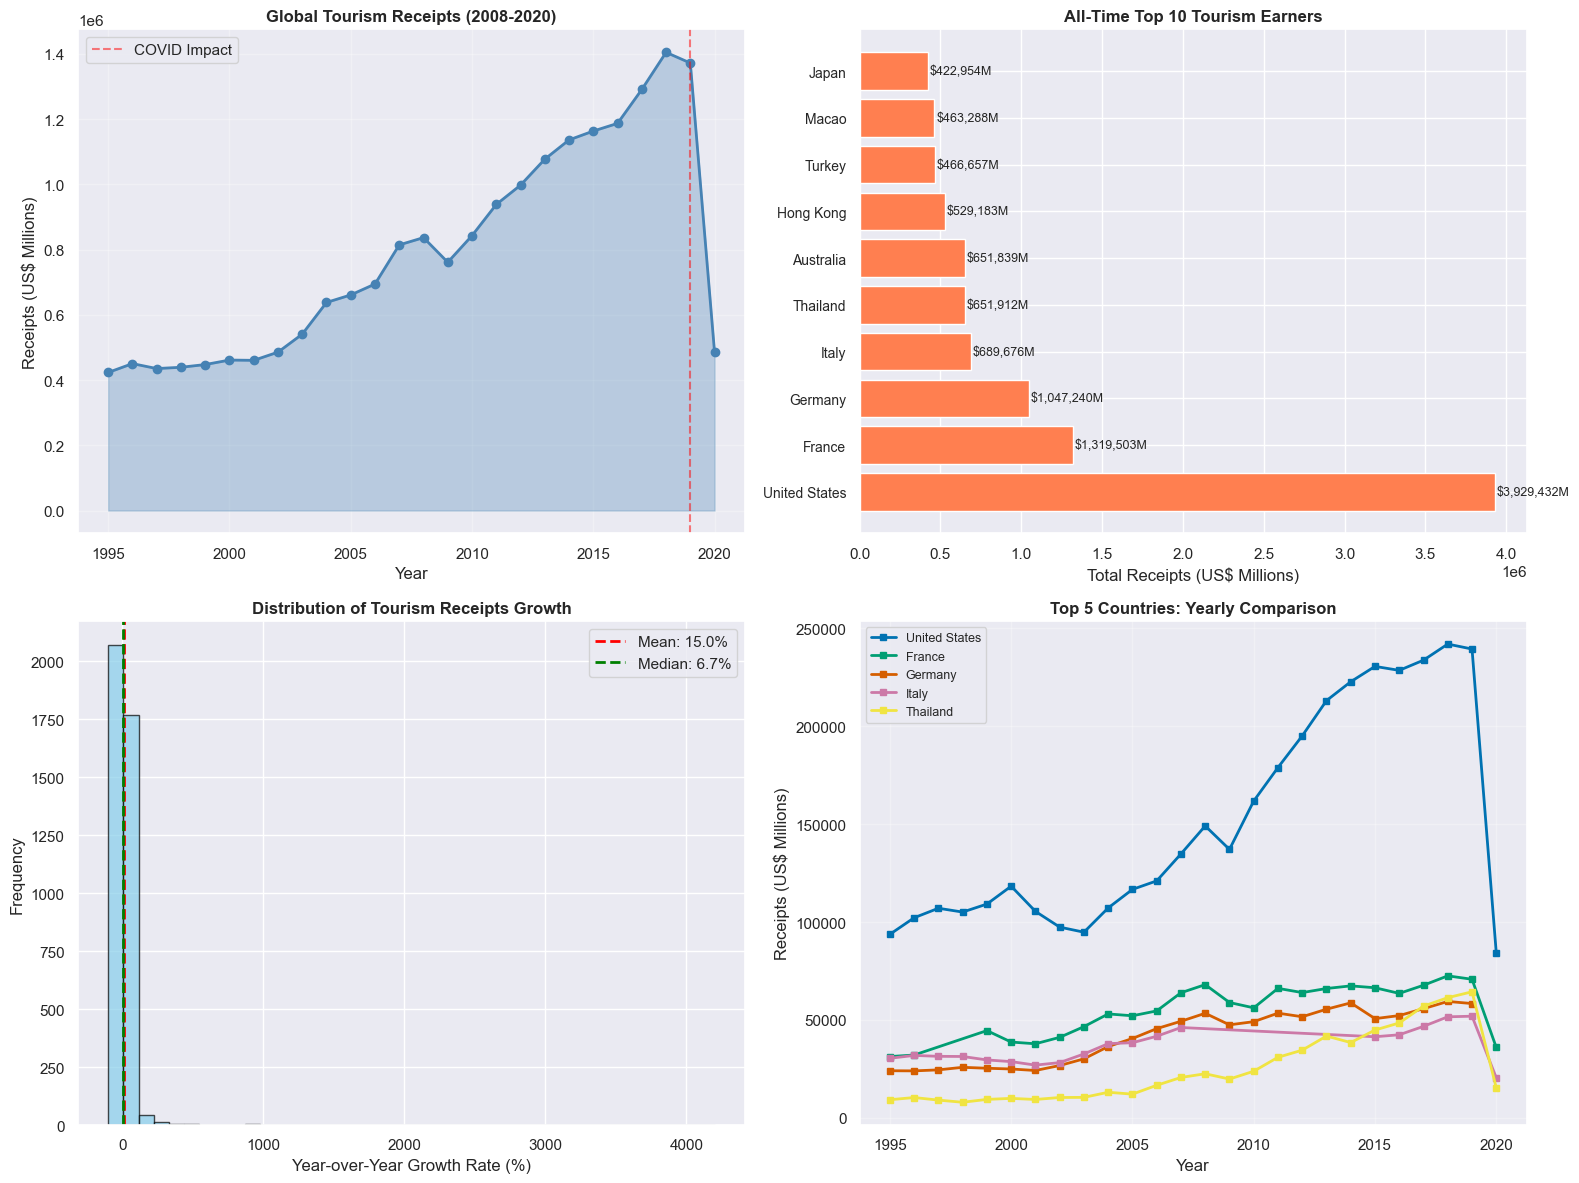

In [89]:
# Create visualisations
fig = plt.figure(figsize=(16, 12))

# Global trend (line plot)
ax1 = plt.subplot(2, 2, 1)
global_totals = df_clean.groupby('year')['value_millions'].sum()
ax1.plot(global_totals.index, global_totals.values, marker='o', linewidth=2, color='steelblue', markersize= 6)
ax1.fill_between(global_totals.index, global_totals.values, alpha=0.3, color='steelblue')
ax1.set_title('Global Tourism Receipts (2008-2020)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Receipts (US$ Millions)')
ax1.grid(True, alpha=0.3)
# Highlight COVID drop
ax1.axvline(x=2019, color='red', linestyle='--', alpha=0.5, label='COVID Impact')
ax1.legend()

# Top 10 countries (horizontal bar chart)
ax2 = plt.subplot(2, 2, 2)
top10 = country_totals.head(10)
bars = ax2.barh(range(len(top10)), top10.values, color='coral')
ax2.set_yticks(range(len(top10)))
ax2.set_yticklabels(top10.index, fontsize=10)
ax2.set_xlabel('Total Receipts (US$ Millions)')
ax2.set_title('All-Time Top 10 Tourism Earners', fontsize=12, fontweight='bold')
# Add value labels
for i, (bar, val) in enumerate(zip(bars, top10.values)):
    ax2.text(val + 10000, bar.get_y() + bar.get_height()/2, f'${val:,.0f}M', va='center', fontsize=9)


# Growth rate distribution histogram
ax3 = plt.subplot(2, 2, 3)
growth_data = df_clean[df_clean['growth_rate'] != 0]['growth_rate']
ax3.hist(growth_data, bins=40, edgecolor='black', alpha=0.7, color='skyblue')
ax3.axvline(growth_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {growth_data.mean():.1f}%')
ax3.axvline(growth_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {growth_data.median():.1f}%')
ax3.set_xlabel('Year-over-Year Growth Rate (%)')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Tourism Receipts Growth', fontsize=12, fontweight='bold')
ax3.legend()


# Top 5 countries - time series comparison
ax4 = plt.subplot(2, 2, 4)
top5_countries = top10.head(5).index
for country in top5_countries:
    country_data = df_clean[df_clean['name'] == country]
    ax4.plot(country_data['year'], country_data['value_millions'], marker='s', linewidth=2, label=country, markersize=4)
ax4.set_title('Top 5 Countries: Yearly Comparison', fontsize=12, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Receipts (US$ Millions)')
ax4.legend(loc='best', fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Year-over-Year % Change

📊 GROWTH HEATMAP FOR TOP COUNTRIES


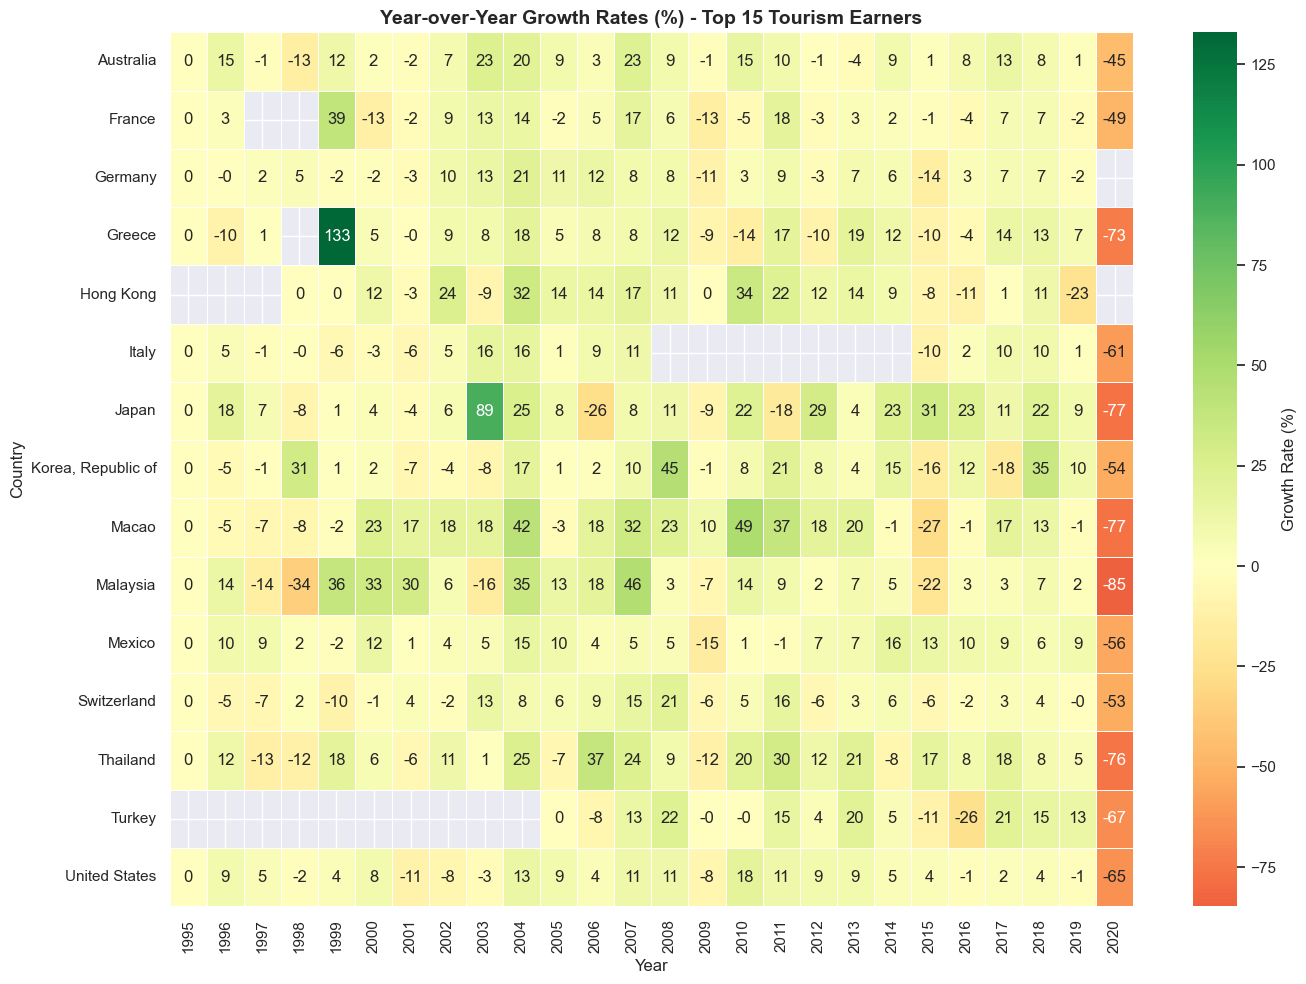


📉 COVID YEAR (2020) IMPACT ON TOP 15:
    Malaysia                       -84.7%
    Macao                          -77.1%
    Japan                          -76.8%
    Thailand                       -76.1%
    Greece                         -73.1%


In [105]:
# Growth heatmap for top countries
print("📊 GROWTH HEATMAP FOR TOP COUNTRIES")
print("="*60)

# Create pivot table for growth rates (top 15 countries)
top15_countries = country_totals.head(15).index
growth_pivot = df_clean[df_clean['name'].isin(top15_countries)].pivot(
    index='name',
    columns='year',
    values='growth_rate'
)

# Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(growth_pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0, cbar_kws={'label': 'Growth Rate (%)'}, linewidths=0.5)
plt.title('Year-over-Year Growth Rates (%) - Top 15 Tourism Earners', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# Highlight COVID year impact
print(f"\n📉 COVID YEAR ({latest_year}) IMPACT ON TOP 15:")
covid_impact = growth_pivot[latest_year].sort_values()
for country, growth in covid_impact.head(5).items():
    print(f"    {country:<30} {growth:+.1f}%")

### Outstanding Performers Analysis

In [111]:
# Identify interesting patterns
print("🔍 STANDOUT PERFORMERS")
print("="*60)

# Best recovery growth despite COVID
if 2020 in df_clean['year'].values:
    covid_growth = df_clean[df_clean['year'] == 2020][['name', 'growth_rate']].dropna()
    covid_growth = covid_growth.sort_values('growth_rate', ascending=False)

    print("\n1️⃣ COUNTRIES THAT GREW IN 2020 (despite COVID):")
    growing_in_2020 = covid_growth[covid_growth['growth_rate'] > 0]
    if len(growing_in_2020) > 0:
        for _, row in growing_in_2020.head(10).iterrows():
            print(f"   {row['name']:<30} +{row['growth_rate']:.1f}%")
        else:
            print("    No countries grew in 2020 - global impact was severe")

# Biggest pre-COVID growth (2019)
pre_covid = df_clean[df_clean['year'] == 2019][['name', 'growth_rate']].dropna()
pre_covid = pre_covid.sort_values('growth_rate', ascending=False)

print("\n2️⃣ FASTEST GROWING IN 2019 (pre-COVID peak):")
for _, row in pre_covid.head(10).iterrows():
    print(f"    {row['name']:<30} +{row['growth_rate']:.1f}%")

# Most improved (2020 vs average)
if 2020 in df_clean['year'].values:
    country_avg = df_clean[df_clean['year'] < 2020].groupby('name')['growth_rate'].mean()
    country_2020 = df_clean[df_clean['year'] == 2020].set_index('name')['growth_rate']
    improvement = country_2020 - country_avg

    print("\n3️⃣ MOST RESILENT (2020 vs historical average):")
    for country, diff in improvement.nlargest(10).items():
        if not pd.isna(diff):
            print(f"    {country:<30} {diff:+.1f}pp vs avg")

🔍 STANDOUT PERFORMERS

1️⃣ COUNTRIES THAT GREW IN 2020 (despite COVID):

2️⃣ FASTEST GROWING IN 2019 (pre-COVID peak):
    Mauritania                     +128.3%
    Guinea                         +121.3%
    Iraq                           +80.9%
    Afghanistan                    +70.0%
    Sint Maarten (Dutch part)      +51.3%
    Myanmar                        +49.8%
    Ghana                          +49.6%
    Zimbabwe                       +49.2%
    Benin                          +37.6%
    Kyrgyzstan                     +36.7%

3️⃣ MOST RESILENT (2020 vs historical average):
    Puerto Rico                    -22.1pp vs avg
    Qatar                          -24.8pp vs avg
    Pakistan                       -25.5pp vs avg
    Luxembourg                     -26.1pp vs avg
    Tonga                          -28.8pp vs avg
    Belgium                        -31.9pp vs avg
    Afghanistan                    -33.5pp vs avg
    Virgin Islands, U.S.           -35.0pp vs avg
    Moldov

### Summary Report

In [117]:
# Cell 10: Generate final summary with proper error handling
print("="*70)
print("TOURISM RECEIPTS ANALYSIS - FINAL SUMMARY")
print("="*70)


# Calculate global totals
global_totals_fresh = df_clean.groupby('year')['value_millions'].sum()
peak_year = int(global_totals_fresh.idxmax())
peak_value = global_totals_fresh.max()

# Calculate COVID impact if data exists
covid_impact = None
decline_percentage = None
if 2019 in df_clean['year'].values and 2020 in df_clean['year'].values:
    receipt_2019 = global_totals_fresh[2019]
    receipt_2020 = global_totals_fresh[2020]
    decline_percentage = ((receipt_2020 - receipt_2019) / receipt_2019) * 100
    covid_impact = f"{decline_percentage:.1f}%"

# Calculate country totals (all-time)
country_totals_fresh = df_clean.groupby('name')['value_millions'].sum().sort_values(ascending=False)
top_earner = country_totals_fresh.index[0]
top_earner_value = country_totals_fresh.iloc[0]

# Calculate average growth rates (excluding zeros)
avg_growth_fresh = df_clean[df_clean['growth_rate'] != 0].groupby('name')['growth_rate'].mean().sort_values(ascending=False)
fastest_growing = avg_growth_fresh.index[0] if len(avg_growth_fresh) > 0 else "N/A"
fastest_growth_rate = avg_growth_fresh.iloc[0] if len(avg_growth_fresh) > 0 else 0

# Calculate most resilient in 2020
most_resilient = "N/A"
if 2020 in df_clean['year'].values:
    country_avg_pre2020 = df_clean[df_clean['year'] < 2020].groupby('name')['growth_rate'].mean()
    country_2020 = df_clean[df_clean['year'] == 2020].set_index('name')['growth_rate']
    improvement = country_2020 - country_avg_pre2020
    improvement = improvement.dropna()
    if len(improvement) > 0:
        most_resilient = improvement.nlargest(1).index[0]

# Calculate total global receipts
total_global = df_clean['value_millions'].sum()
avg_annual = global_totals_fresh.mean()

# Calculate data quality metrics
total_missing = df_clean.isnull().sum().sum()
duplicates = df_clean.duplicated().sum()
negative_values = (df_clean['value_$'] < 0).sum()

# Determine data quality score
if total_missing == 0 and duplicates == 0 and negative_values == 0:
    quality_score = "A+ (Perfect - No issues found)"
elif total_missing < 100 and duplicates == 0:
    quality_score = "A (Excellent - Minor missing values)"
elif total_missing < 1000:
    quality_score = "B+ (Good - Some missing values)"
else:
    quality_score = "B (Satisfactory - Needs review)"

# Create summary dictionary
summary = {
    'Time Period': f"{df_clean['year'].min()} - {df_clean['year'].max()}",
    'Countries Analyzed': f"{df_clean['name'].nunique():,}",
    'Total Global Receipts (All Time)': f"${total_global:,.0f}M",
    'Average Annual Global Receipts': f"${avg_annual:,.0f}M",
    'Peak Year': peak_year,
    'Peak Year Value': f"${peak_value:,.0f}M",
    'Top Earner (All Time)': f"{top_earner} (${top_earner_value:,.0f}M)",
    'Fastest Growing (Avg %)': f"{fastest_growing} ({fastest_growth_rate:.1f}%)" if fastest_growing != "N/A" else "N/A",
    'COVID Impact (2019→2020)': covid_impact if covid_impact else "Data not available",
    'Most Resilient in 2020': most_resilient,
    'Data Quality Score': quality_score
}

print("\n📊 SUMMARY STATISTICS:")
print("-" * 50)
for key, value in summary.items():
    print(f"   {key}: {value}")

print("\n" + "="*70)
print("✅ Analysis complete! Ready for presentation.")
print("="*70)

# Save cleaned and enhanced dataset
try:
    df_clean.to_csv('tourism_receipts_enhanced.csv', index=False)
    print("\n💾 Enhanced dataset saved as 'tourism_receipts_enhanced.csv'")
except:
    print("\n⚠️ Could not save enhanced dataset")

# Save summary statistics
try:
    summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
    summary_df.to_csv('tourism_analysis_summary.csv', index=False)
    print("💾 Summary saved as 'tourism_analysis_summary.csv'")
except:
    print("⚠️ Could not save summary file")

TOURISM RECEIPTS ANALYSIS - FINAL SUMMARY

📊 SUMMARY STATISTICS:
--------------------------------------------------
   Time Period: 1995 - 2020
   Countries Analyzed: 203
   Total Global Receipts (All Time): $20,444,723M
   Average Annual Global Receipts: $786,335M
   Peak Year: 2018
   Peak Year Value: $1,404,666M
   Top Earner (All Time): United States ($3,929,432M)
   Fastest Growing (Avg %): Congo, The Democratic Republic of the (722.5%)
   COVID Impact (2019→2020): -64.7%
   Most Resilient in 2020: Puerto Rico
   Data Quality Score: B+ (Good - Some missing values)

✅ Analysis complete! Ready for presentation.

💾 Enhanced dataset saved as 'tourism_receipts_enhanced.csv'
💾 Summary saved as 'tourism_analysis_summary.csv'
